# Prueba de volumen de outliers — red de detección ampliada (hojas vs "no-hojas")

**Objetivo:** estimar **cuántas** imágenes del dataset *no* son fotos sobre hojas de mandioca
(raíces, tubérculos cortados, palos, personas, carteles, paisajes…), ampliando el umbral de
detección del Experimento 5.6 de `01_EDA_mandioca.ipynb` (regla final: **33 imágenes = 0,13 %**).

Esto es una **prueba exploratoria para contabilizar**, no una decisión final:

* **No** se modifica `datos/dataset original/` y **no** se toca `01_EDA_mandioca.ipynb`.
* Misma filosofía de clasificación Hoja vs "no-hoja" del EDA 01 (máscaras HSV + greenness
  cromático + celdas verdes), pero con **umbrales relajados** y compuertas **OR** → red más ancha.
* Todo se **copia** a una carpeta aparte para revisión visual:
  `datos/cambios 02 - prueba volumen outliers/outliers_prueba/`.

## Reglas que se prueban

| Red | Rama A — verde relajado (**AND**) | Rama B — suelo (**OR**) | Rama C — neutro (**OR**) |
|---|---|---|---|
| **base** (EDA 01) | `pct_verde < 0.15 y verde_suave < 0.035 y celdas_verdes < 3` (+ 8 manuales) | — | — |
| **red 1 · ampliada** | `pct_verde < 0.35 y verde_suave < 0.08 y celdas_verdes < 8` | `pct_suelo > 0.40` | `pct_neutro > 0.45` |
| **red 2 · muy ampliada** | `pct_verde < 0.45 y verde_suave < 0.12 y celdas_verdes < 12` | `pct_suelo > 0.30` | `pct_neutro > 0.35` |

Red = **A OR B OR C**. Intuición de cada rama:

* **A** — captura raíces/palos con pasto de fondo: se tolera *algo* de verde sin llegar a la
  estructura completa de una planta (la regla base exigía las 3 condiciones a la vez y con
  un poco de follaje la imagen "escapaba" del filtro).
* **B** — captura el objeto invasor por su color (cáscara de raíz, tierra, madera, pulpa).
* **C** — captura el interior blanco/crema de la mandioca, cuadernos y fondos neutros.

## Métricas (idénticas a las del EDA 01 — Fase 5.6)

* `pct_verde` — máscara HSV hoja (H 30–110°, S ≥ 50, V ≥ 60).
* `pct_neutro` — S ≤ 30 y (V ≤ 60 ó ≥ 210): sombras, blanco, gris.
* `pct_suelo` — H 5–35°, S 40–140, V 60–190: tierra, cáscara, madera.
* `verde_suave` — fracción de píxeles con `G − max(R,B) > 4 y G > 20` a 160×120
  (greenness cromático, robusto al brillo).
* `celdas_verdes` — nº de celdas 20×20 (de 48) con **> 20 %** de píxeles verdes.


In [1]:
import os, time, shutil, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

NOMBRE = {
    0: "CBB (bacteriosis)",
    1: "CBSD (rayas marrones)",
    2: "CGM (moteado verde)",
    3: "CMD (mosaico)",
    4: "Saludable",
}
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 110,
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})


def detectar_entorno():
    try:
        import google.colab  # noqa: F401
        return "colab"
    except Exception:
        return "local"


ENTORNO = detectar_entorno()
print("Entorno:", ENTORNO, "| semilla:", SEED)

CAND_CSV = [
    Path("datos/dataset original/labels.csv"),
    Path("dataset original/labels.csv"),
    Path("../datos/dataset original/labels.csv"),
    Path(r"D:\final_inteligencia\datos\dataset original\labels.csv"),
]
CAND_MET = [
    Path("datos/cambios 01 - no hojas/labels_cambios.csv"),
    Path(r"D:\final_inteligencia\datos\cambios 01 - no hojas\labels_cambios.csv"),
]
CAND_IMG = [
    Path("datos/dataset original/images"),
    Path("dataset original/images"),
    Path(r"D:\final_inteligencia\datos\dataset original\images"),
]

if ENTORNO == "colab" and not any(p.exists() for p in CAND_CSV):
    print("En Colab: subi labels.csv por el panel de archivos.")
    from google.colab import files
    subido = files.upload()
    CAND_CSV.insert(0, Path(list(subido)[0]))

RUTA_CSV = next((p for p in CAND_CSV if p.exists()), None)
assert RUTA_CSV is not None, "No se encontro labels.csv en ninguna ruta candidata"
RUTA_MET = next((p for p in CAND_MET if p.exists()), None)
RAIZ_IMG = next((p for p in CAND_IMG if p.exists()), None)
disp_img = RAIZ_IMG is not None

df = pd.read_csv(RUTA_CSV)
print("CSV      :", RUTA_CSV.resolve())
print("Metricas :", RUTA_MET.resolve() if RUTA_MET else "NO encontradas -> se recalculan")
print("Imagenes :", RAIZ_IMG.resolve() if RAIZ_IMG else "NO encontradas -> se omiten copias/montajes")
print("Filas CSV:", len(df))


Entorno: local | semilla: 42
CSV      : D:\final_inteligencia\datos\dataset original\labels.csv
Metricas : D:\final_inteligencia\datos\cambios 01 - no hojas\labels_cambios.csv
Imagenes : D:\final_inteligencia\datos\dataset original\images
Filas CSV: 26337


## Métricas + reproducción de la regla base

Se reutilizan las métricas ya calculadas por el EDA 01 (`labels_cambios.csv`, 26,337 filas).
Si no existieran, se recalculan con **la misma función** del EDA (≈ 16 min sobre todo el dataset).

Antes de ampliar, se verifica que la regla base se reproduce **exacta**: 25 automáticas
+ 8 manuales = **33** = `flag_no_hoja` del EDA 01.

In [2]:
def metricas_hoja(path):
    # Funcion identica a la del EDA 01 (Fase 5.6) - solo se usa si faltan las metricas.
    with Image.open(path) as im:
        hsv = np.asarray(im.convert("HSV"), dtype=np.int16)
        gris = np.asarray(im.convert("L"), dtype=np.float32)
        rgb120 = np.asarray(im.convert("RGB").resize((160, 120)), dtype=np.int16)
    Hdeg = hsv[..., 0] * 360.0 / 255.0
    S, V = hsv[..., 1], hsv[..., 2]
    verde = ((Hdeg >= 30) & (Hdeg <= 110) & (S >= 50) & (V >= 60)).mean()
    neutro = ((S <= 30) & ((V <= 60) | (V >= 210))).mean()
    suelo = ((Hdeg >= 5) & (Hdeg <= 35) & (S >= 40) & (S <= 140) & (V >= 60) & (V <= 190)).mean()
    h32 = gris.shape[0] // 32 * 32
    w32 = gris.shape[1] // 32 * 32
    bloques = (gris[:h32, :w32].reshape(h32 // 32, 32, w32 // 32, 32)
               .transpose(0, 2, 1, 3).reshape(-1, 32 * 32))
    pct_plano = float((bloques.std(axis=1) < 8).mean())
    R120, G120, B120 = rgb120[..., 0], rgb120[..., 1], rgb120[..., 2]
    verde_cromo = float(((G120 > R120 + 8) & (G120 > B120 + 8) & (G120 > 35)).mean())
    m_suave = (G120 - np.maximum(R120, B120) > 4) & (G120 > 20)
    verde_suave = float(m_suave.mean())
    celdas = m_suave.reshape(6, 20, 8, 20).transpose(0, 2, 1, 3).reshape(48, 400).mean(axis=1)
    celdas_verdes = int((celdas > 0.20).sum())
    return verde, neutro, suelo, pct_plano, verde_cromo, verde_suave, celdas_verdes


t0 = time.time()
if RUTA_MET is not None:
    met = pd.read_csv(RUTA_MET)
    origen_met = "reutilizada de " + str(RUTA_MET)
else:
    assert RAIZ_IMG is not None, "Sin labels_cambios.csv ni carpeta de imagenes: no hay metricas."
    print("Recalculando metricas sobre todas las imagenes (~16 min)...")
    files_all = sorted(f for f in os.listdir(RAIZ_IMG) if f.lower().endswith(".jpg"))
    filas = []
    for i, f in enumerate(files_all, 1):
        v, n, s, pl, vc, vs, cv = metricas_hoja(RAIZ_IMG / f)
        filas.append({"image_id": f, "pct_verde": v, "pct_neutro": n, "pct_suelo": s,
                      "pct_plano": pl, "score_hoja": v - 0.5 * pl - 0.3 * n,
                      "verde_cromo": vc, "verde_suave": vs, "celdas_verdes": cv})
        if i % 5000 == 0:
            print(f"  {i}/{len(files_all)} procesadas...")
    met = pd.DataFrame(filas).merge(df, on="image_id", how="left")
    origen_met = "recalculada en esta corrida"

assert len(met) == len(df), f"metricas={len(met)} != csv={len(df)}"
print(f"Origen de metricas: {origen_met} ({len(met):,} filas, {time.time() - t0:.1f} s)")

RAICES_MANUALES = {
    "1004389140.jpg", "2139839273.jpg", "4203623611.jpg", "746746526.jpg",
    "2698282165.jpg", "1905119159.jpg", "274726002.jpg", "3058561440.jpg",
}
flag_auto = (met.pct_verde < 0.15) & (met.verde_suave < 0.035) & (met.celdas_verdes < 3)
flag_base = flag_auto | met.image_id.isin(RAICES_MANUALES)
n_auto = int(flag_auto.sum())
n_man = int((flag_base & ~flag_auto).sum())
print(f"Regla base EDA 01 reproducida: {int(flag_base.sum())} = {n_auto} automaticas + {n_man} manuales")
if "flag_no_hoja" in met.columns:
    coincide = bool((flag_base == met.flag_no_hoja).all())
    print("Coincide 100 % con flag_no_hoja del EDA 01:", coincide)
    assert coincide, "La regla base no reproduce flag_no_hoja"


Origen de metricas: reutilizada de datos\cambios 01 - no hojas\labels_cambios.csv (26,337 filas, 0.1 s)
Regla base EDA 01 reproducida: 33 = 25 automaticas + 8 manuales
Coincide 100 % con flag_no_hoja del EDA 01: True


In [3]:
UMBRALES = {
    "base (EDA 01)":       dict(verde=0.15, suave=0.035, celdas=3,  suelo=None,  neutro=None),
    "red 1 - ampliada":    dict(verde=0.35, suave=0.08,  celdas=8,  suelo=0.40, neutro=0.45),
    "red 2 - muy ampliada": dict(verde=0.45, suave=0.12, celdas=12, suelo=0.30, neutro=0.35),
}


def aplicar_red(m, u):
    apagado = pd.Series(False, index=m.index)
    ramaA = (m.pct_verde < u["verde"]) & (m.verde_suave < u["suave"]) & (m.celdas_verdes < u["celdas"])
    ramaB = (m.pct_suelo > u["suelo"]) if u["suelo"] is not None else apagado
    ramaC = (m.pct_neutro > u["neutro"]) if u["neutro"] is not None else apagado
    return ramaA, ramaB, ramaC, (ramaA | ramaB | ramaC)


flags, detalles = {}, {}
for nombre, u in UMBRALES.items():
    A, B, C, m = aplicar_red(met, u)
    detalles[nombre] = (A, B, C)
    flags[nombre] = m
flags["base (EDA 01)"] = flag_base   # la base agrega ademas las 8 raices/palos manuales

for nombre in UMBRALES:
    A, B, C = detalles[nombre]
    print(f"{nombre:24s} A(verde)={int(A.sum()):5d}  B(suelo)={int(B.sum()):5d}  "
          f"C(neutro)={int(C.sum()):4d}  -> union {int(flags[nombre].sum()):5d}")


base (EDA 01)            A(verde)=   25  B(suelo)=    0  C(neutro)=   0  -> union    33
red 1 - ampliada         A(verde)=   87  B(suelo)=   32  C(neutro)=   1  -> union   117
red 2 - muy ampliada     A(verde)=  149  B(suelo)=  169  C(neutro)=   4  -> union   298


## Conteo y proporcionalidad

* **n (regla)** — cuántas marca cada red por sí sola.
* **union con base** — la red **más las 33 ya confirmadas** en el EDA 01 (así ninguna
  de las conocidas se pierde al cambiar de umbral): es el total que se copia a la carpeta.
* **% del dataset** — sobre las **26,337** imágenes del dataset original.
* **quedarían** — cuántas imágenes quedarían disponibles para entrenar si se descartara esa unión.

In [4]:
total = len(df)
filas = []
for nombre in UMBRALES:
    m = flags[nombre]
    union = m | flag_base
    filas.append({
        "red": nombre,
        "n (regla)": int(m.sum()),
        "nuevas vs base": int((m & ~flag_base).sum()),
        "union con base": int(union.sum()),
        "% del dataset": round(100 * union.mean(), 2),
        "quedarían": total - int(union.sum()),
    })
tabla = pd.DataFrame(filas)
display(tabla)

print(f"Dataset original: {total:,} imagenes")
print(f"Base EDA 01      : {int(flag_base.sum()):,} ({100 * flag_base.mean():.2f} %) "
      f"| ya estaban en 'cambios 01 - no hojas/outliers'")
for nombre in UMBRALES:
    if nombre == "base (EDA 01)":
        continue
    u = int((flags[nombre] | flag_base).sum())
    print(f"{nombre:19s}: {u:,} candidatas ({100 * u / total:.2f} %) "
          f"| quedarian {total - u:,} imagenes")

fuera1 = int((flag_base & ~flags["red 1 - ampliada"]).sum())
fuera2 = int((flag_base & ~flags["red 2 - muy ampliada"]).sum())
print(f"\nbase fuera de red 1: {fuera1} | base fuera de red 2: {fuera2}")
print("red 2 contiene a red 1:",
      bool((flags["red 1 - ampliada"] & ~flags["red 2 - muy ampliada"]).sum() == 0))


,red,n (regla),nuevas vs base,union con base,% del dataset,quedarían
0,base (EDA 01),33,0,33,0.13,26304
1,red 1 - ampliada,117,86,119,0.45,26218
2,red 2 - muy ampliada,298,265,298,1.13,26039


Dataset original: 26,337 imagenes
Base EDA 01      : 33 (0.13 %) | ya estaban en 'cambios 01 - no hojas/outliers'
red 1 - ampliada   : 119 candidatas (0.45 %) | quedarian 26,218 imagenes
red 2 - muy ampliada: 298 candidatas (1.13 %) | quedarian 26,039 imagenes

base fuera de red 1: 2 | base fuera de red 2: 0
red 2 contiene a red 1: True


## Copia de las candidatas a una carpeta aparte

Se limpia la carpeta de corridas previas y se copian **solo copias** (el original queda intacto):

```
datos/cambios 02 - prueba volumen outliers/
├── outliers_prueba/
│   ├── 01_base_confirmadas/            <- las 33 ya validadas en el EDA 01
│   ├── 02_red_ampliada_nuevas/         <- capturas NUEVAS de la red ampliada  ← revisar primero
│   └── 03_red_muy_ampliada_nuevas/     <- solo la red muy ampliada (red más laxa)
├── montajes/                           <- JPEG con las mismas imágenes en grilla
├── labels_outliers_prueba.csv          <- metricas + flags de las 26,337
├── outliers_prueba.csv                 <- solo las candidatas
└── resumen_outliers_prueba.md          <- conteos y proporciones
```

Cada imagen cae en **una sola** carpeta (partición disjunta): primero la base, después lo nuevo
de la red 1, después lo nuevo de la red 2.

In [5]:
m_base = flags["base (EDA 01)"]
m_r1 = flags["red 1 - ampliada"] & ~m_base
m_r2 = flags["red 2 - muy ampliada"] & ~m_base & ~flags["red 1 - ampliada"]
GRUPOS = [
    ("01_base_confirmadas", m_base),
    ("02_red_ampliada_nuevas", m_r1),
    ("03_red_muy_ampliada_nuevas", m_r2),
]
for nombre, m in GRUPOS:
    print(f"{nombre:26s} {int(m.sum()):5d}")
print(f"{'TOTAL copias':26s} {int((m_base | m_r1 | m_r2).sum()):5d}")
contenida1 = int((flags["red 1 - ampliada"] & ~flags["red 2 - muy ampliada"]).sum()) == 0
contenida2 = int((flag_base & ~flags["red 2 - muy ampliada"]).sum()) == 0
print(f"Jerarquia: red1 dentro de red2 = {contenida1} | base dentro de red2 = {contenida2}")

pros = RUTA_CSV.resolve()
RAIZ_PROY = pros.parents[2] if len(pros.parents) > 2 else pros.parent
CAMBIOS2 = RAIZ_PROY / "datos" / "cambios 02 - prueba volumen outliers"
if CAMBIOS2.exists():
    shutil.rmtree(CAMBIOS2)
(CAMBIOS2 / "montajes").mkdir(parents=True)
print("Carpeta de salida:", CAMBIOS2)

if not disp_img:
    print("OMITIDO: sin carpeta de imagenes (no hay copias).")
else:
    t0 = time.time()
    for nombre, m in GRUPOS:
        destino = CAMBIOS2 / "outliers_prueba" / nombre
        destino.mkdir(parents=True, exist_ok=True)
        ids = sorted(met.loc[m, "image_id"])
        for f in ids:
            shutil.copy(RAIZ_IMG / f, destino / f)
        print(f"  {nombre}: {len(ids)} copias")
    print(f"Copia de imagenes: {time.time() - t0:.1f} s")


01_base_confirmadas           33
02_red_ampliada_nuevas        86
03_red_muy_ampliada_nuevas   179
TOTAL copias                 298
Jerarquia: red1 dentro de red2 = True | base dentro de red2 = True
Carpeta de salida: D:\final_inteligencia\datos\cambios 02 - prueba volumen outliers


  01_base_confirmadas: 33 copias


  02_red_ampliada_nuevas: 86 copias


  03_red_muy_ampliada_nuevas: 179 copias
Copia de imagenes: 0.6 s


In [6]:
met_out = met.copy()
met_out["flag_base"] = m_base
met_out["flag_red1"] = flags["red 1 - ampliada"]
met_out["flag_red2"] = flags["red 2 - muy ampliada"]
met_out["marcada"] = m_base | m_r1 | m_r2
met_out["carpeta"] = np.select(
    [m_base, m_r1, m_r2],
    ["01_base_confirmadas", "02_red_ampliada_nuevas", "03_red_muy_ampliada_nuevas"],
    default="",
)
met_out.to_csv(CAMBIOS2 / "labels_outliers_prueba.csv", index=False)
solo_marcadas = met_out.loc[met_out.marcada].sort_values(["carpeta", "pct_verde"])
solo_marcadas.to_csv(CAMBIOS2 / "outliers_prueba.csv", index=False)
print(f"labels_outliers_prueba.csv: {len(met_out):,} filas (metricas + flags de todo el dataset)")
print(f"outliers_prueba.csv       : {len(solo_marcadas):,} filas (solo candidatas)")
print(solo_marcadas.carpeta.value_counts().to_string())


labels_outliers_prueba.csv: 26,337 filas (metricas + flags de todo el dataset)
outliers_prueba.csv       : 298 filas (solo candidatas)
carpeta
03_red_muy_ampliada_nuevas    179
02_red_ampliada_nuevas         86
01_base_confirmadas            33


## Montajes — validación visual de las candidatas

Cada miniatura lleva el nombre del archivo y las métricas abreviadas
(**vd** = `pct_verde` · **vs** = `verde_suave` · **cel** = `celdas_verdes` ·
**su** = `pct_suelo` · **nu** = `pct_neutro`), ordenadas de **menor a mayor `pct_verde`**
(las más sospechosas primero). Las mismas grillas se guardan como JPEG en `montajes/`.

**Qué buscar al revisar:** raíces y tubérculos cortados, palos/troncos, personas, carteles o
libros, paisajes, hojas *de otras plantas*. **Dudas legítimas** (dejar a criterio): fotos de la
planta entera donde domina el suelo, hojas muy oscuras o desenfocadas.

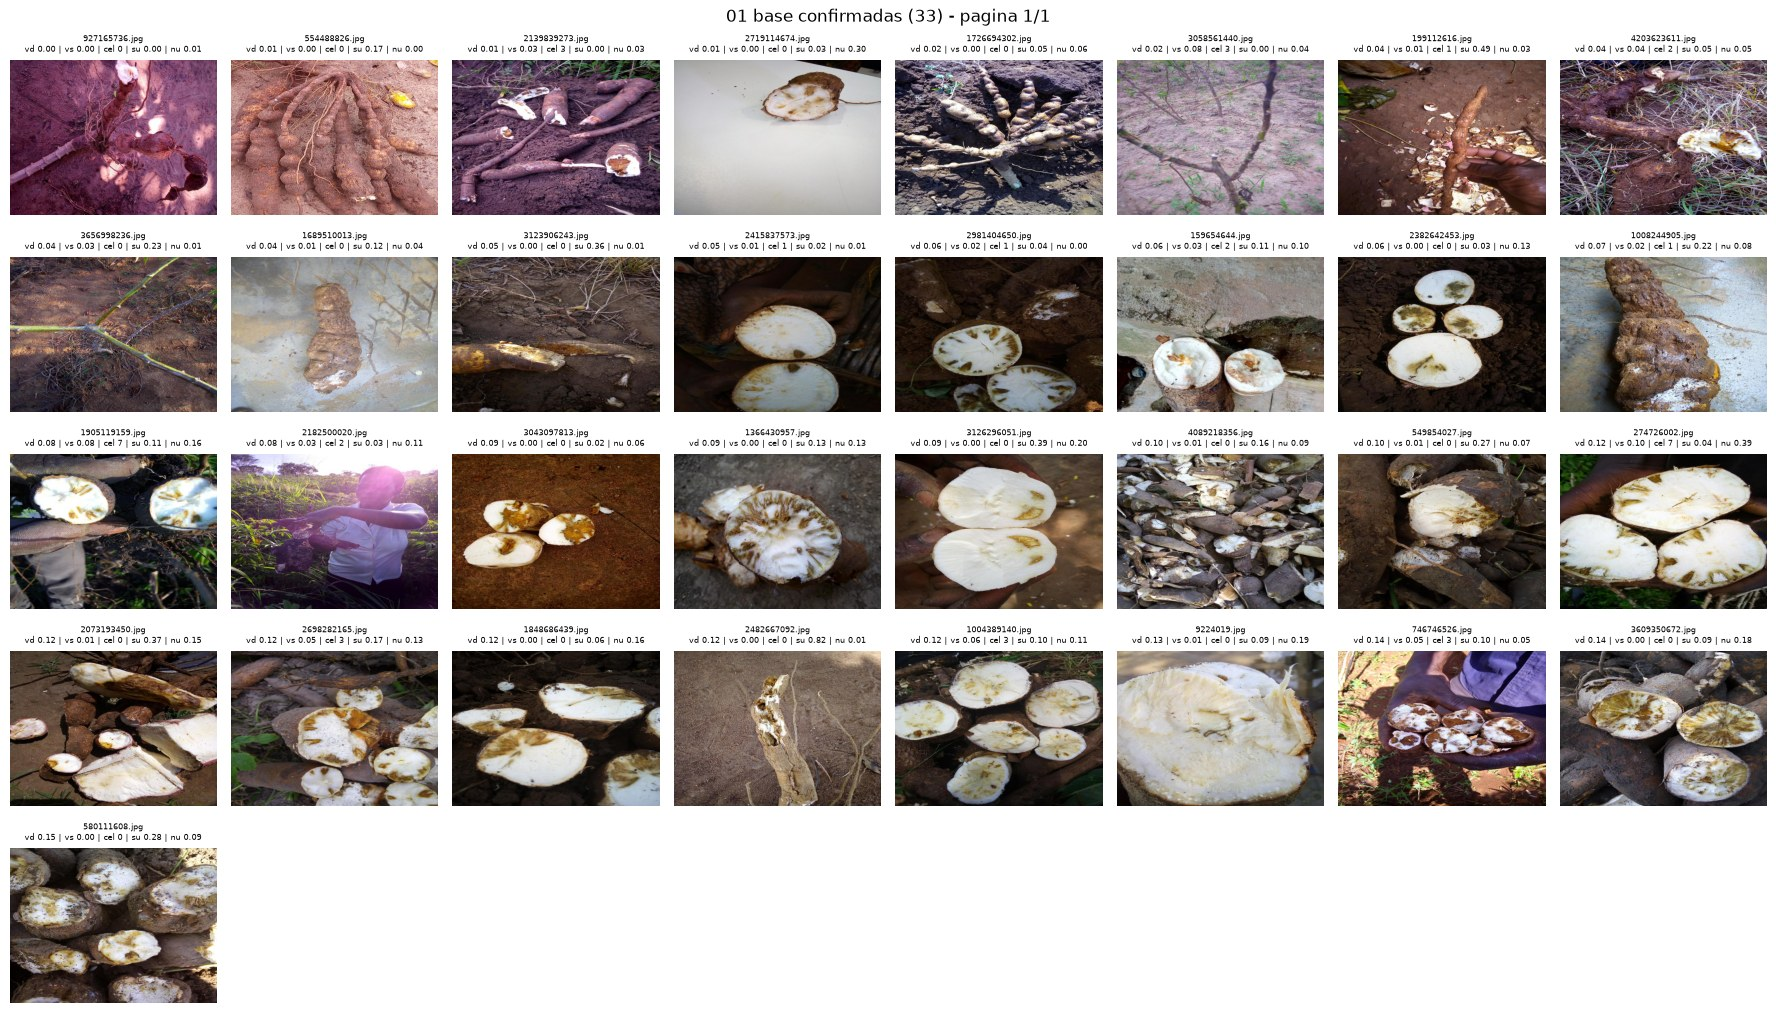

01 base confirmadas (33): 33 imagenes en 1 pagina(s) -> 01_base_pXX.jpg


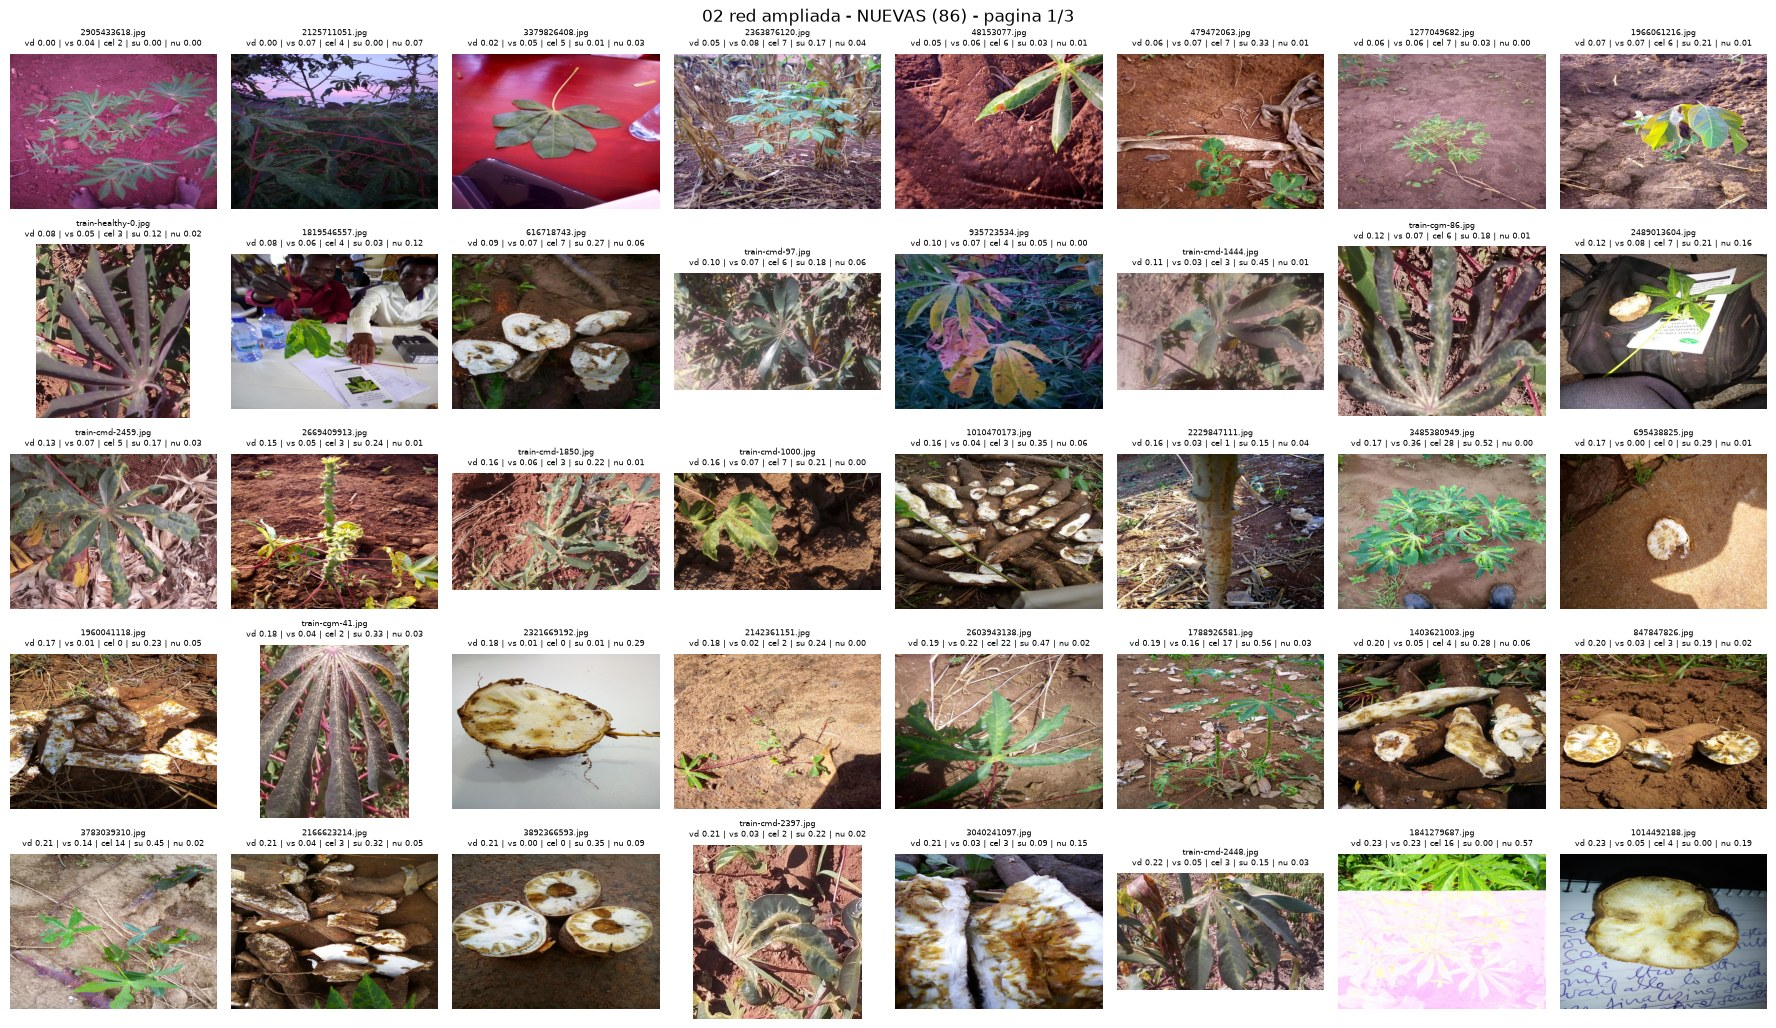

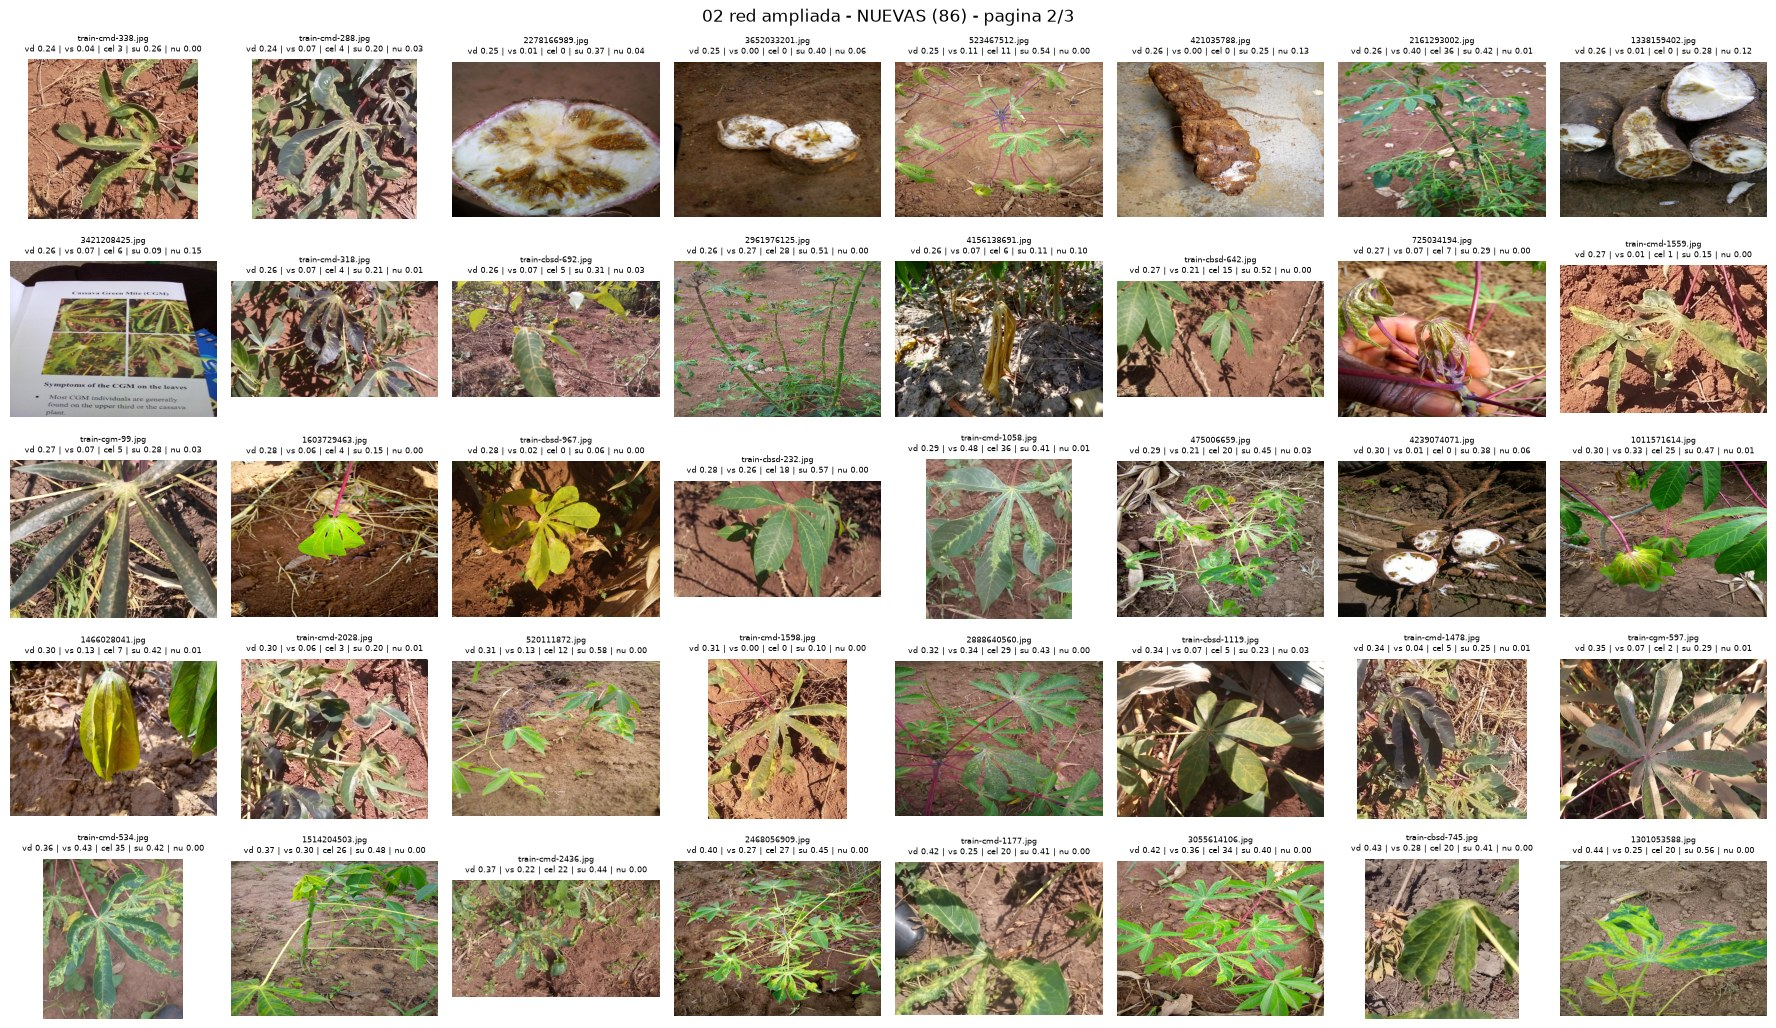

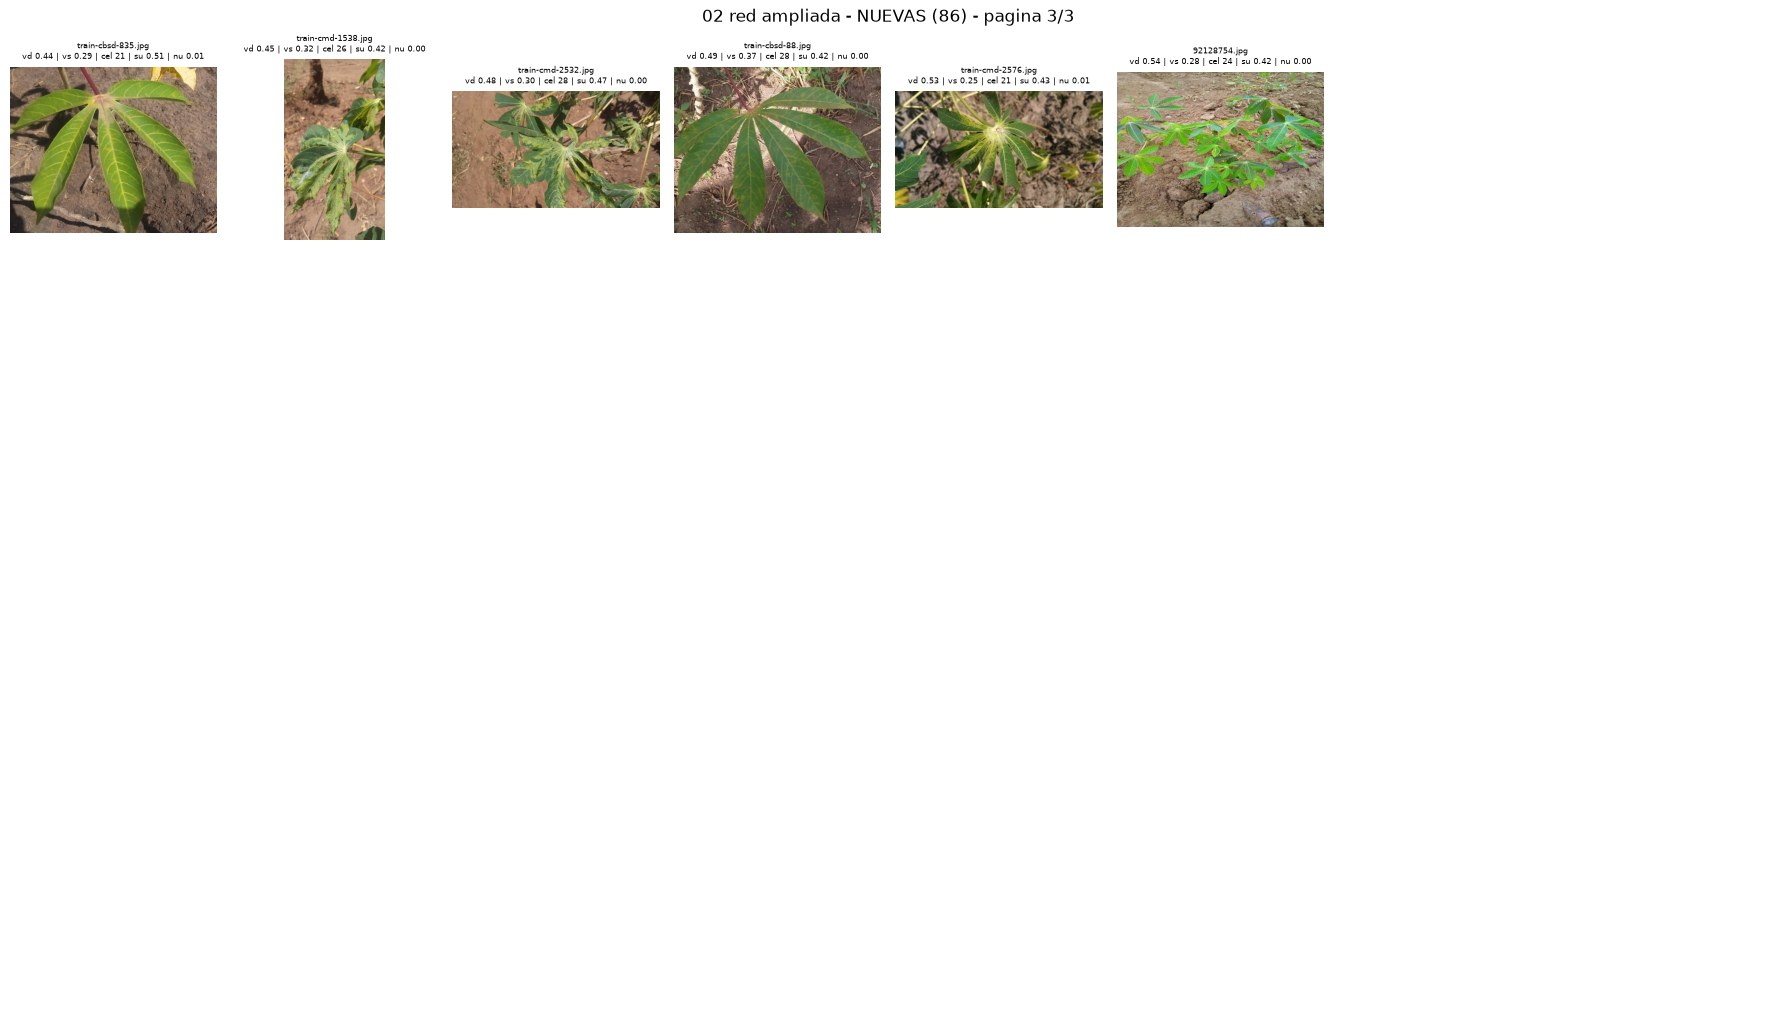

02 red ampliada - NUEVAS (86): 86 imagenes en 3 pagina(s) -> 02_ampliada_pXX.jpg


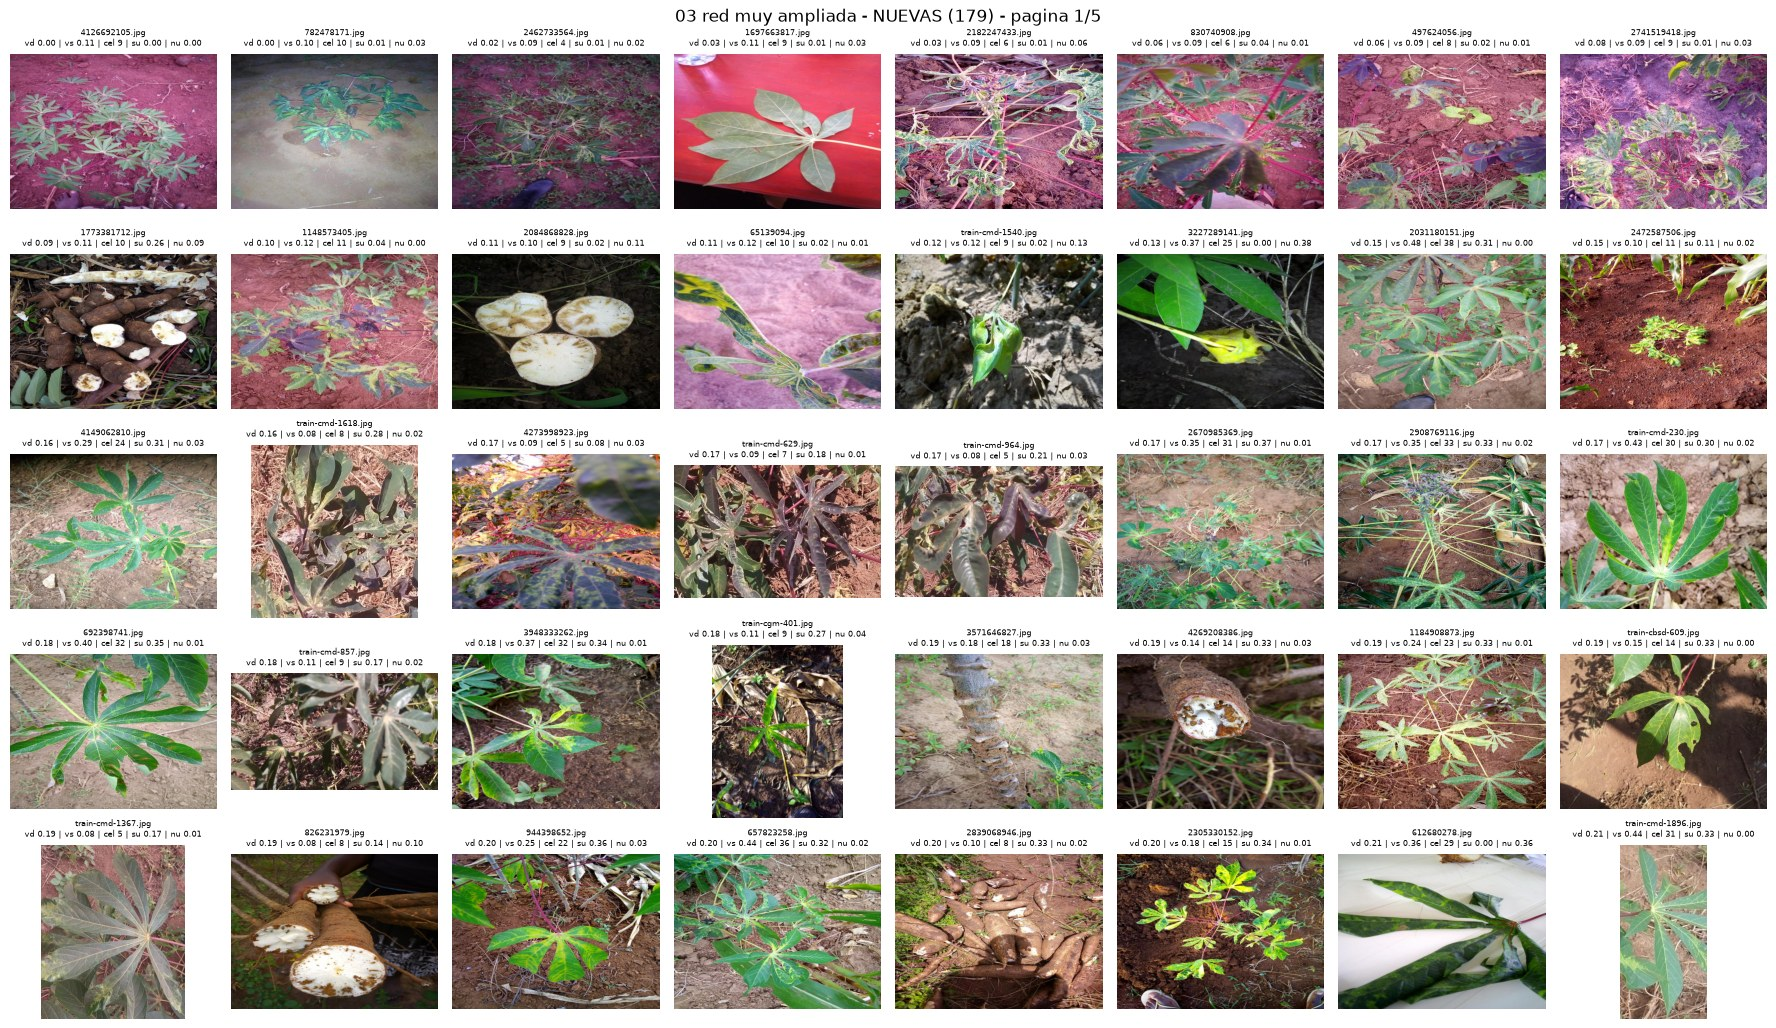

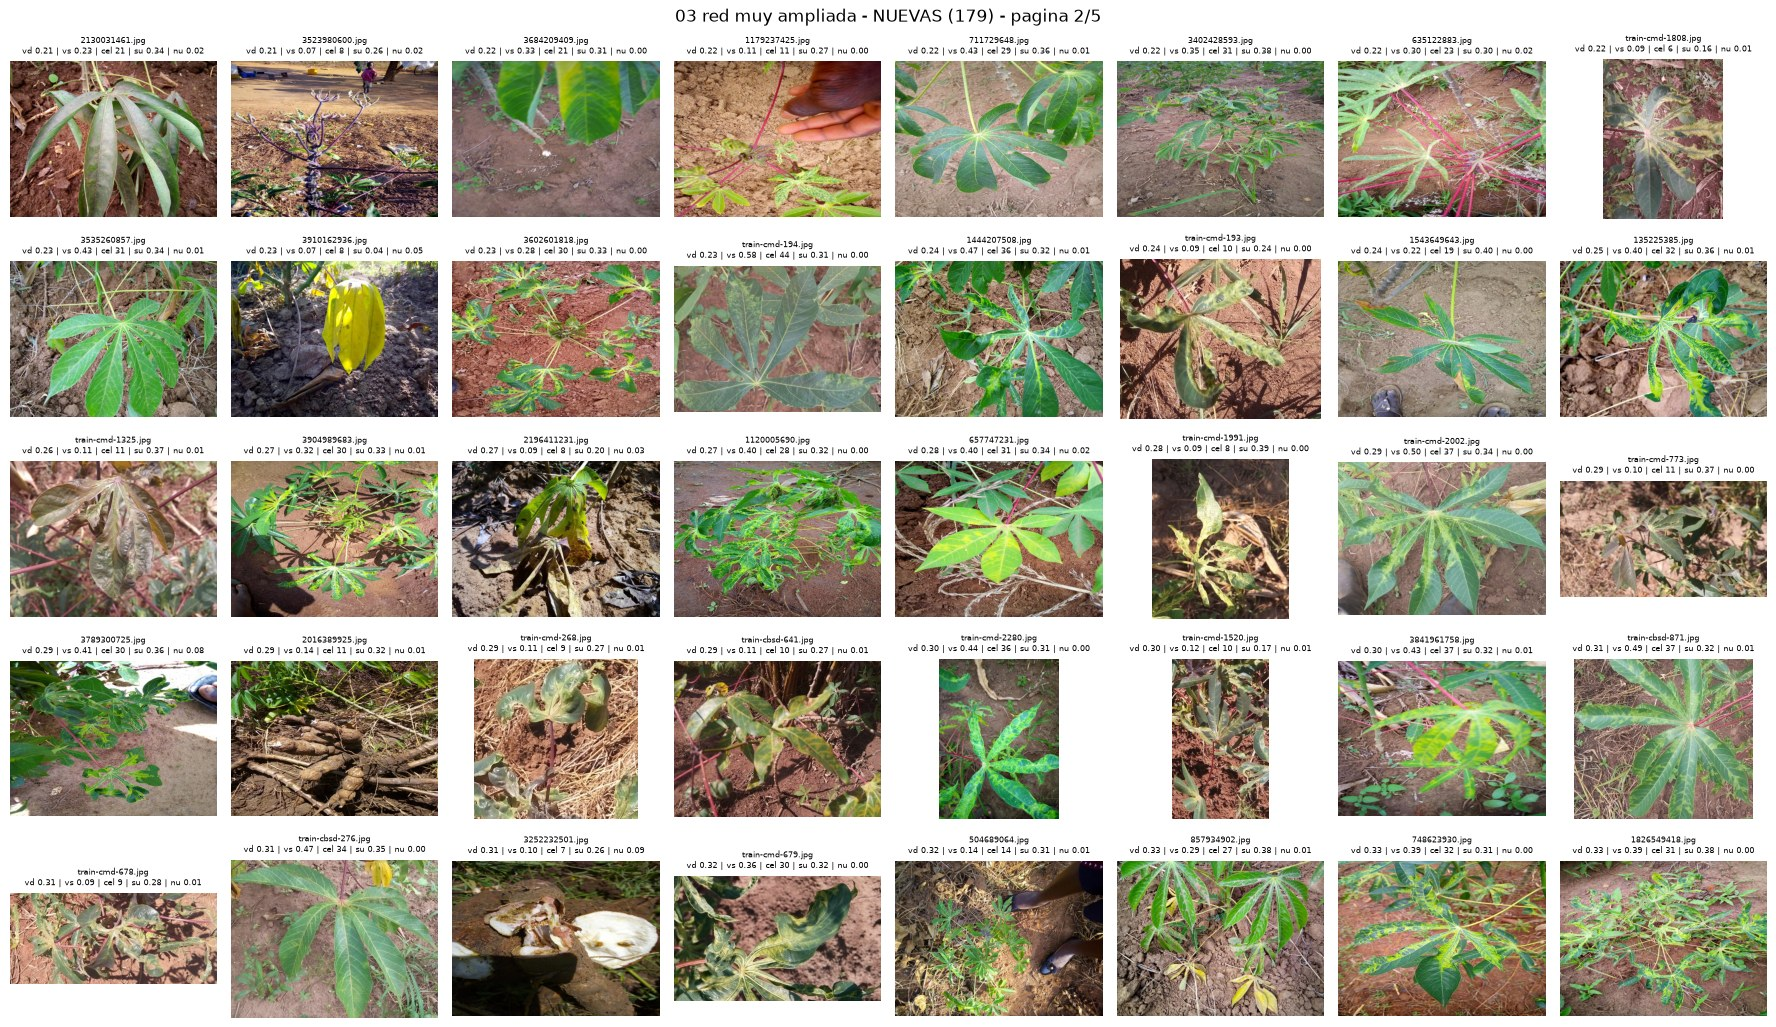

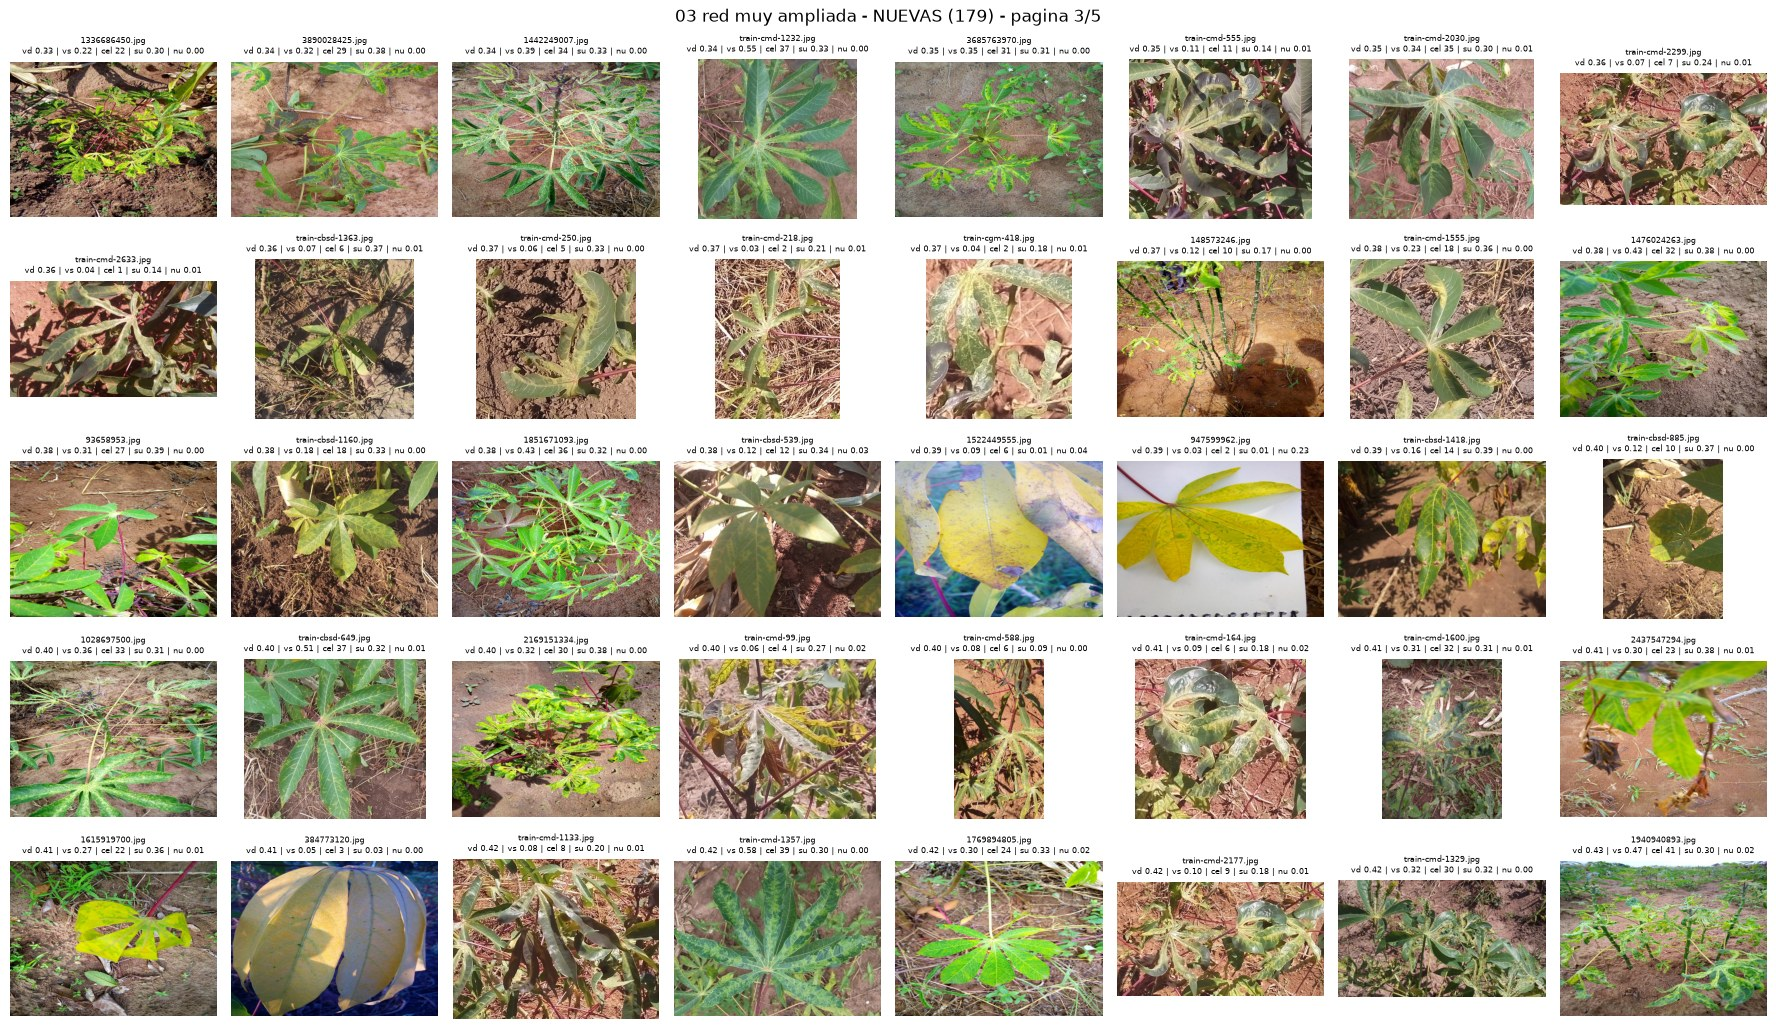

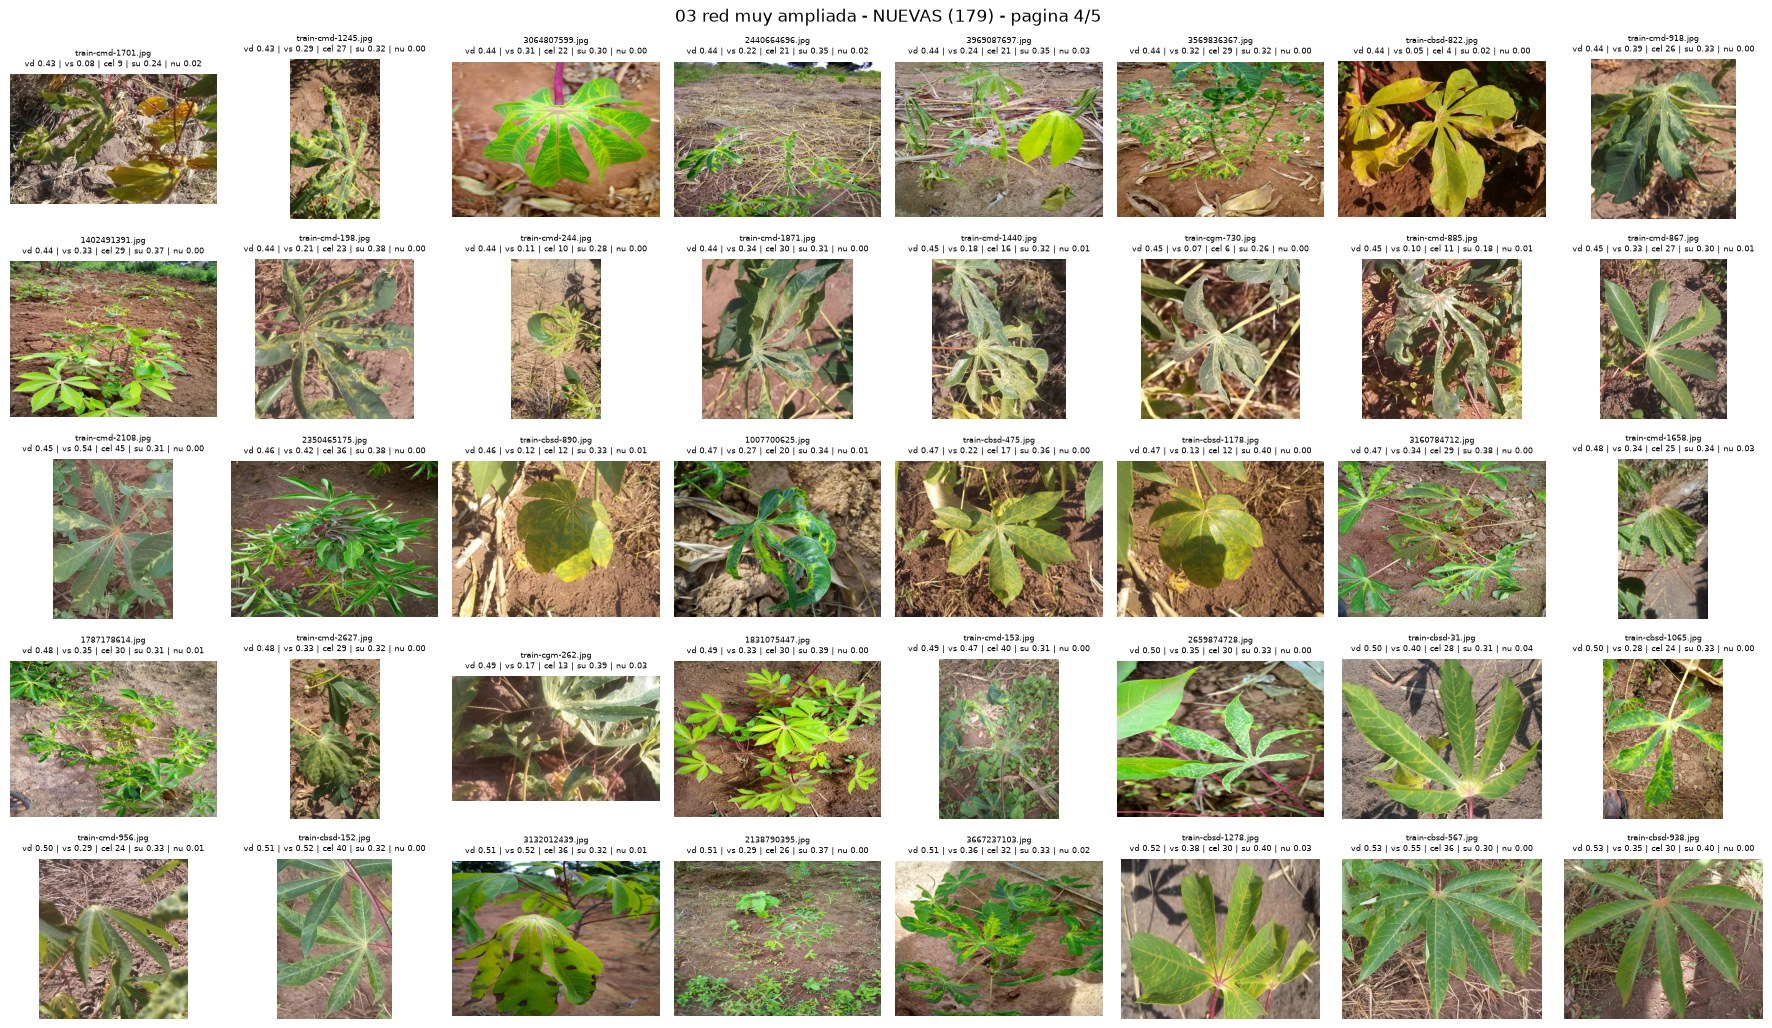

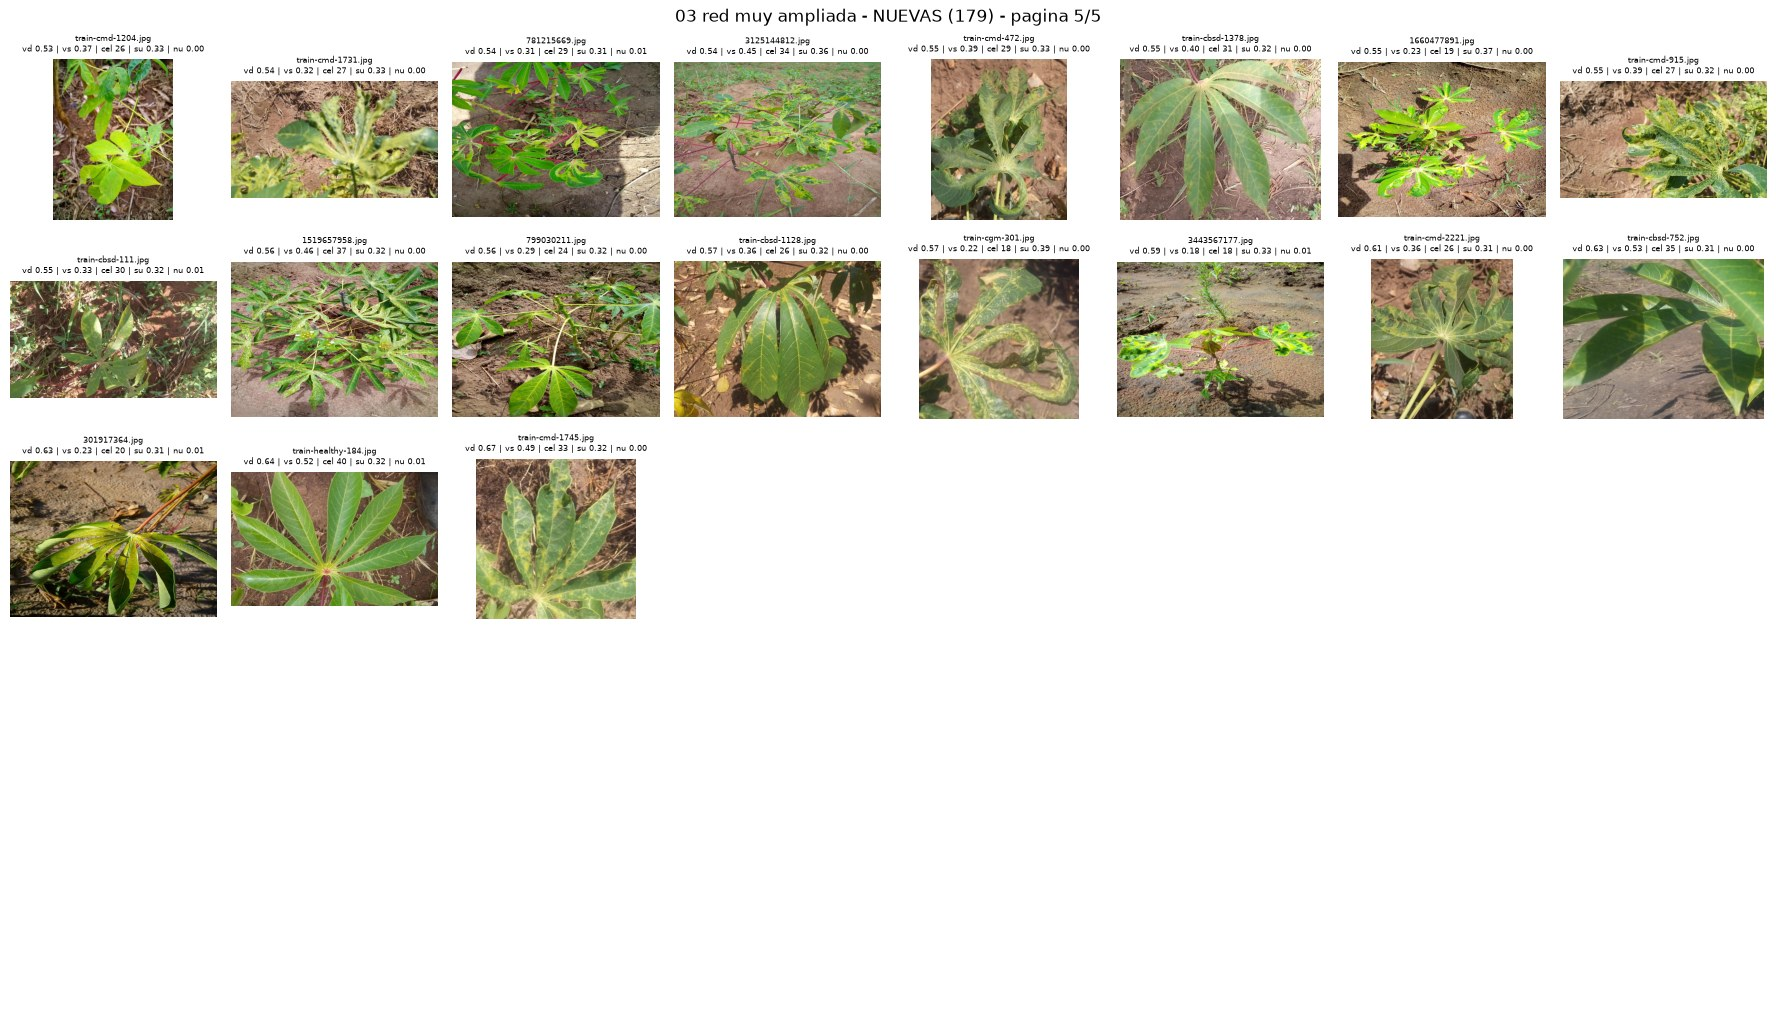

03 red muy ampliada - NUEVAS (179): 179 imagenes en 5 pagina(s) -> 03_muy_ampliada_pXX.jpg


In [7]:
from IPython.display import Image as ImagenIPy, display as mostrar_ipy


def montajes(sub, prefijo, titulo, ncols=8, nrows=5):
    sub = sub.sort_values("pct_verde").reset_index(drop=True)
    por_pag = ncols * nrows
    npag = max(1, -(-len(sub) // por_pag))
    for p in range(npag):
        chunk = sub.iloc[p * por_pag:(p + 1) * por_pag]
        fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.35, nrows * 2.2))
        for k, ax in enumerate(axes.ravel()):
            ax.axis("off")
            if k >= len(chunk):
                continue
            row = chunk.iloc[k]
            with Image.open(RAIZ_IMG / row.image_id) as im:
                ax.imshow(im)
            ax.set_title(
                f"{row.image_id}\n"
                f"vd {row.pct_verde:.2f} | vs {row.verde_suave:.2f} | cel {int(row.celdas_verdes)} | "
                f"su {row.pct_suelo:.2f} | nu {row.pct_neutro:.2f}",
                fontsize=6)
        fig.suptitle(f"{titulo} - pagina {p + 1}/{npag}", fontsize=13)
        fig.tight_layout()
        ruta = CAMBIOS2 / "montajes" / f"{prefijo}_p{p + 1:02d}.jpg"
        fig.savefig(ruta, dpi=95, bbox_inches="tight", pil_kwargs={"quality": 88})
        plt.close(fig)
        mostrar_ipy(ImagenIPy(filename=str(ruta)))
    print(f"{titulo}: {int(len(sub))} imagenes en {npag} pagina(s) -> {prefijo}_pXX.jpg")


if not disp_img:
    print("OMITIDO: sin carpeta de imagenes.")
else:
    montajes(met[m_base], "01_base", f"01 base confirmadas ({int(m_base.sum())})")
    montajes(met[m_r1], "02_ampliada", f"02 red ampliada - NUEVAS ({int(m_r1.sum())})")
    montajes(met[m_r2], "03_muy_ampliada", f"03 red muy ampliada - NUEVAS ({int(m_r2.sum())})")


## Proporcionalidad por clase y por fuente

Se cruza lo marcado con `label` (CBB/CBSD/CGM/CMD/Saludable) y `source` (2019/2020) para ver
si las candidatas se concentran en alguna clase o campaña. **Atención:** un exceso en una clase
puede ser señal de *falsos positivos* (p. ej. lesiones marrones de CBSD que disparan `pct_suelo`,
u hojas oscuras que disparan las ramas A/C), no de outliers reales.

In [8]:
u1 = flags["red 1 - ampliada"] | flag_base
u2 = flags["red 2 - muy ampliada"] | flag_base
marcada = m_base | m_r1 | m_r2


def cuenta(mask):
    return met.loc[mask].groupby("label").size().reindex(range(5), fill_value=0)


por_clase = pd.DataFrame({
    "clase": [NOMBRE[i] for i in range(5)],
    "n dataset": met.groupby("label").size().reindex(range(5)).values,
    "base": cuenta(flag_base).values,
    "red 1 (union)": cuenta(u1).values,
    "red 2 (union)": cuenta(u2).values,
})
por_clase["% de la clase (red 2)"] = (100 * por_clase["red 2 (union)"]
                                      / por_clase["n dataset"]).round(2)
por_clase["% del dataset (red 2)"] = (100 * por_clase["red 2 (union)"]
                                      / len(met)).round(3)
display(por_clase)

fuentes = sorted(met.source.unique())
por_fuente = pd.DataFrame({
    "source": fuentes,
    "n dataset": [int((met.source == s).sum()) for s in fuentes],
    "base": [int((flag_base & (met.source == s)).sum()) for s in fuentes],
    "red 1 (union)": [int((u1 & (met.source == s)).sum()) for s in fuentes],
    "red 2 (union)": [int((u2 & (met.source == s)).sum()) for s in fuentes],
})
por_fuente["% de la fuente (red 2)"] = (100 * por_fuente["red 2 (union)"]
                                        / por_fuente["n dataset"]).round(2)
display(por_fuente)

print(f"Total dataset      : {len(met):,}")
print(f"Total marcadas     : {int(marcada.sum()):,} ({100 * marcada.mean():.2f} %)")
print(f"Disponibles (resto): {len(met) - int(marcada.sum()):,}")


,clase,n dataset,base,red 1 (union),red 2 (union),% de la clase (red 2),% del dataset (red 2)
0,CBB (bacteriosis),1492,0,2,4,0.27,0.015
1,CBSD (rayas marrones),3476,32,61,103,2.96,0.391
2,CGM (moteado verde),3017,0,8,26,0.86,0.099
3,CMD (mosaico),15462,0,39,142,0.92,0.539
4,Saludable,2890,1,9,23,0.80,0.087


,source,n dataset,base,red 1 (union),red 2 (union),% de la fuente (red 2)
0,2019,4940,0,34,120,2.43
1,2020,21397,33,85,178,0.83


Total dataset      : 26,337
Total marcadas     : 298 (1.13 %)
Disponibles (resto): 26,039


In [9]:
resumen = f"""# Prueba de volumen de outliers - red ampliada (hojas vs no-hojas)

* **Fecha:** {time.strftime("%d/%m/%Y %H:%M")}
* **Dataset base:** datos/dataset original (intacto, {len(df):,} imagenes)
* **Origen de metricas:** {origen_met}
* **Metodo:** mismas metricas del EDA 01 (HSV + greenness cromatico + celdas), umbrales
  relajados y compuertas OR. El dataset original y 01_EDA_mandioca.ipynb NO se modifican.

## Reglas

| red | rama A (verde, AND) | rama B (suelo, OR) | rama C (neutro, OR) |
|---|---|---|---|
| base (EDA 01) | pct_verde<0.15 y verde_suave<0.035 y celdas_verdes<3 (+8 manuales) | - | - |
| red 1 - ampliada | pct_verde<0.35 y verde_suave<0.08 y celdas_verdes<8 | pct_suelo>0.40 | pct_neutro>0.45 |
| red 2 - muy ampliada | pct_verde<0.45 y verde_suave<0.12 y celdas_verdes<12 | pct_suelo>0.30 | pct_neutro>0.35 |

## Conteos (union con base = red + las 33 ya confirmadas)

| red | n (regla) | union con base | % del dataset | quedarian |
|---|---|---|---|---|
| base (EDA 01) | {int(flags['base (EDA 01)'].sum())} | {int(flag_base.sum())} | {100 * flag_base.mean():.2f} % | {len(df) - int(flag_base.sum()):,} |
| red 1 - ampliada | {int(flags['red 1 - ampliada'].sum())} | {int(u1.sum())} | {100 * u1.mean():.2f} % | {len(df) - int(u1.sum()):,} |
| red 2 - muy ampliada | {int(flags['red 2 - muy ampliada'].sum())} | {int(u2.sum())} | {100 * u2.mean():.2f} % | {len(df) - int(u2.sum()):,} |

* Nuevas vs base - red 1: {int((flags['red 1 - ampliada'] & ~flag_base).sum())} | red 2: {int((flags['red 2 - muy ampliada'] & ~flag_base).sum())}
* Reparto por carpeta: 01_base_confirmadas = {int(m_base.sum())} | 02_red_ampliada_nuevas = {int(m_r1.sum())} | 03_red_muy_ampliada_nuevas = {int(m_r2.sum())}

## Por clase (union red 2)

"""
for _, r in por_clase.iterrows():
    resumen += (f"* {r['clase']}: {int(r['red 2 (union)'])} de {int(r['n dataset'])} "
                f"({r['% de la clase (red 2)']} % de la clase)\n")
resumen += f"""
## Salidas en esta carpeta

* outliers_prueba/01_base_confirmadas/ -> {int(m_base.sum())} copias (confirmadas en EDA 01)
* outliers_prueba/02_red_ampliada_nuevas/ -> {int(m_r1.sum())} copias (revisar primero)
* outliers_prueba/03_red_muy_ampliada_nuevas/ -> {int(m_r2.sum())} copias (red mas laxa)
* montajes/ -> grillas JPEG de todas las candidatas
* labels_outliers_prueba.csv -> metricas + flags de las {len(met):,}
* outliers_prueba.csv -> solo las {int(marcada.sum()):,} candidatas
* resumen_outliers_prueba.md -> este archivo

## Limites

* Las ramas B/C pueden marcar HOJAS enfermas: lesiones marrones ~ pct_suelo y sombras
  ~ pct_neutro. La rama A puede marcar hojas oscuras/desenfocadas con poco verde.
* Esto es un CONTEO exploratorio: la decision final se toma despues de revisar la carpeta.
"""
with open(CAMBIOS2 / "resumen_outliers_prueba.md", "w", encoding="utf-8") as fh:
    fh.write(resumen)
print(resumen)
print("resumen_outliers_prueba.md escrito en", CAMBIOS2)


# Prueba de volumen de outliers - red ampliada (hojas vs no-hojas)

* **Fecha:** 01/10/2026 22:51
* **Dataset base:** datos/dataset original (intacto, 26,337 imagenes)
* **Origen de metricas:** reutilizada de datos\cambios 01 - no hojas\labels_cambios.csv
* **Metodo:** mismas metricas del EDA 01 (HSV + greenness cromatico + celdas), umbrales
  relajados y compuertas OR. El dataset original y 01_EDA_mandioca.ipynb NO se modifican.

## Reglas

| red | rama A (verde, AND) | rama B (suelo, OR) | rama C (neutro, OR) |
|---|---|---|---|
| base (EDA 01) | pct_verde<0.15 y verde_suave<0.035 y celdas_verdes<3 (+8 manuales) | - | - |
| red 1 - ampliada | pct_verde<0.35 y verde_suave<0.08 y celdas_verdes<8 | pct_suelo>0.40 | pct_neutro>0.45 |
| red 2 - muy ampliada | pct_verde<0.45 y verde_suave<0.12 y celdas_verdes<12 | pct_suelo>0.30 | pct_neutro>0.35 |

## Conteos (union con base = red + las 33 ya confirmadas)

| red | n (regla) | union con base | % del dataset | quedarian |
|---|---|---|---|-

## Cómo revisar la carpeta (y qué significa cada número)

1. **`02_red_ampliada_nuevas/`** — es el corazón de la prueba: lo que la red ampliada
   captura **y el EDA 01 no vio**. Abrir la carpeta y contar cuántas son realmente
   "no-hoja" (raíces, cortes, palos, personas, carteles, paisaje).
2. **`03_red_muy_ampliada_nuevas/`** — red más laxa: sirve para ver **hasta dónde** sube el
   conteo si se afloja más; se espera que tenga más falsos positivos (hojas sobre suelo).
3. **`01_base_confirmadas/`** — las 33 ya validadas del EDA 01 (referencia, no hace falta
   re-revisarlas).
4. Los montajes en `montajes/*.jpg` permiten revisar todo rápido sin abrir imagen por imagen.

**Riesgos a mirar en la revisión:**

* Rama B (`pct_suelo`): puede agarrar **hojas con lesiones marrones** (CBSD/CBB) o tierra
  debajo de la hoja → falsos positivos.
* Rama C (`pct_neutro`): sombras profundas o fondo blanco → falsos positivos.
* Rama A (verde relajado): hojas oscuras/desenfocadas o plantas enteras donde domina el suelo.

**Regla del EDA 01 que se mantiene:** primero se mira, después se fija el umbral. Este notebook
solo cuenta y copia; no descarta nada del dataset original.